# Day 17

---


In [1]:
import grama as gr
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
DF = gr.Intention()

# Set figure options
plt.rcParams['figure.figsize'] = [6, 6] # Need square aspect ratio for gradients to appear normal
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower


## Uncertainty Propagation

Set up some models to work with

Calling plot_sinew_outputs....


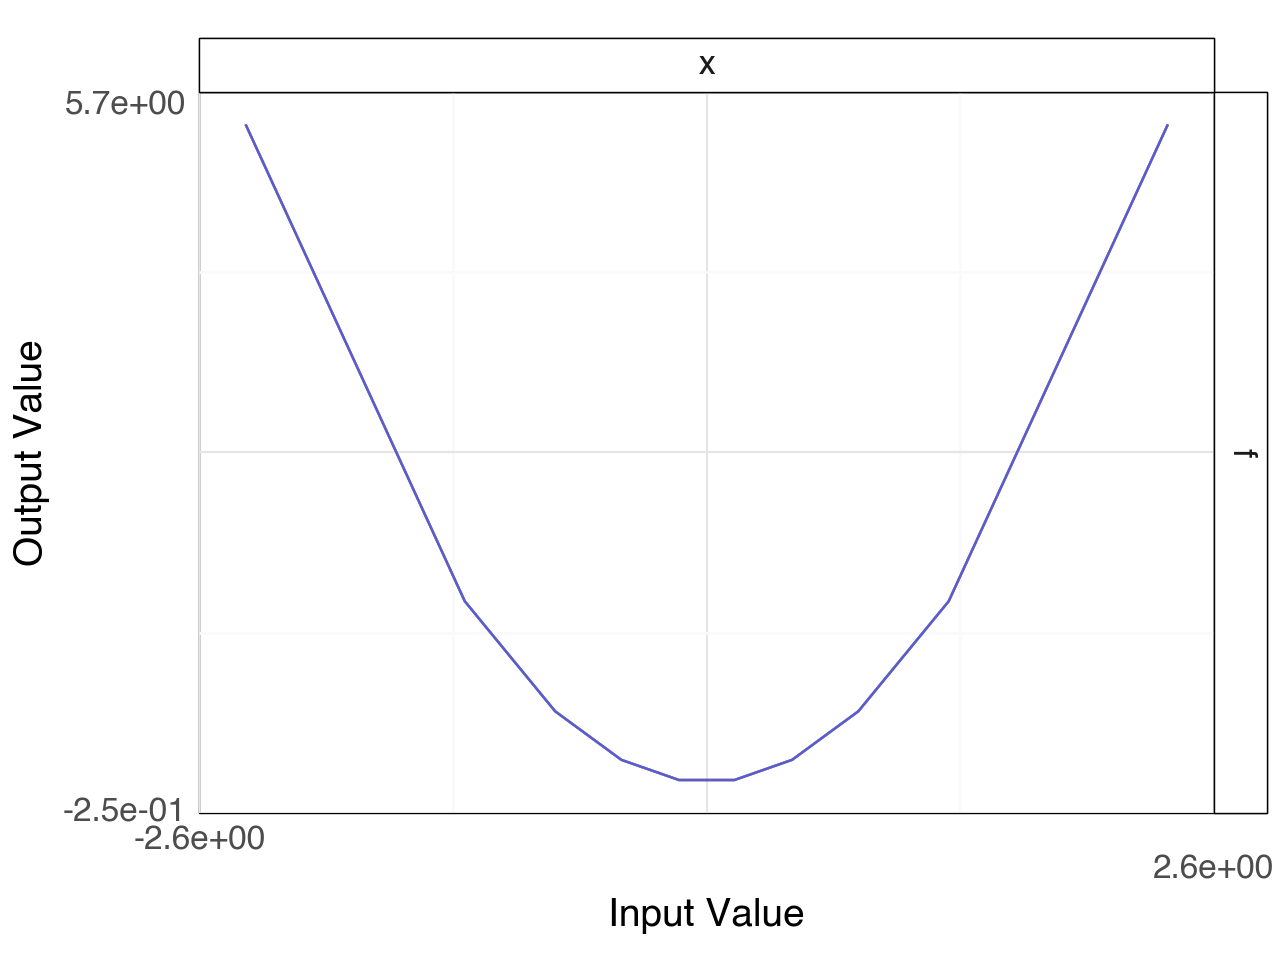

<Figure Size: (640 x 480)>

In [34]:
md_quad1d = (
    gr.Model()
    >> gr.cp_vec_function(
        fun=lambda df: (
            df
            >> gr.tf_mutate(f=df.x**2)
        ),
        var=["x", "y"],
        out=["f"],
    )
    >> gr.cp_marginals(
        x=gr.marg_mom("norm", mean=0, sd=1),
    )
    # >> gr.cp_copula_independence()
)

(
    md_quad1d
    >> gr.ev_sinews(df_det="nom")
    # >> gr.ev_sample(df_det="nom", n=1000)
    >> gr.pt_auto()
)

Calling plot_hists....


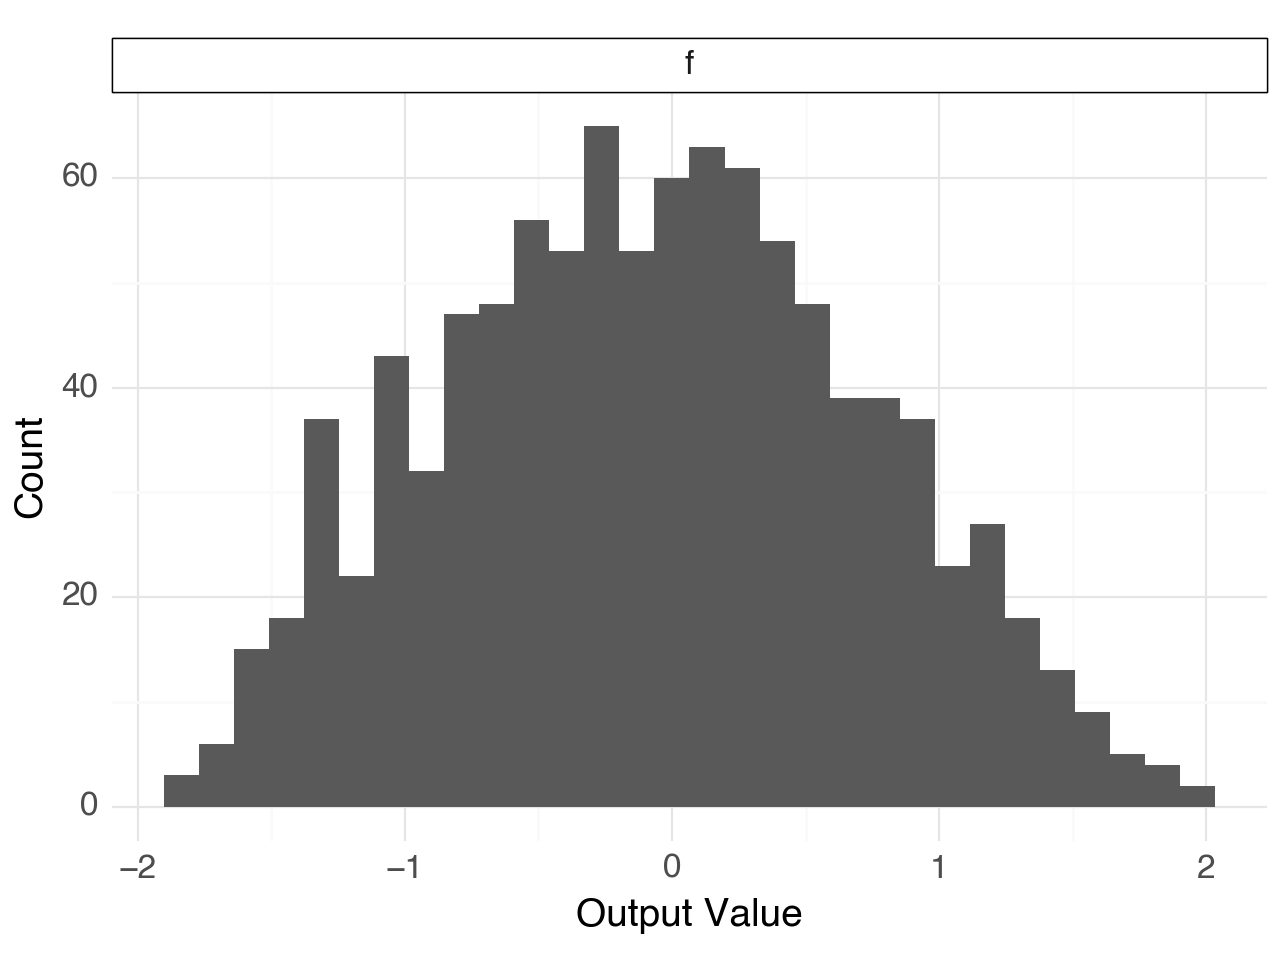

<Figure Size: (640 x 480)>

In [35]:
md_linear2d = (
    gr.Model()
    >> gr.cp_vec_function(
        fun=lambda df: (
            df
            >> gr.tf_mutate(f=df.x + df.y)
        ),
        var=["x", "y"],
        out=["f"],
    )
    >> gr.cp_marginals(
        x=gr.marg_mom("uniform", lo=-1, up=+1),
        y=gr.marg_mom("uniform", lo=-1, up=+1),
    )
    >> gr.cp_copula_independence()
)

(
    md_linear2d
    # >> gr.ev_sinews(df_det="nom")
    >> gr.ev_sample(df_det="nom", n=1000)
    >> gr.pt_auto()
)

### Simple sampling

If we have an input distribution $X \sim \rho$, and a function that evaluates $f(x)$, then we have an output distribution $f(X) \sim \psi$.

We've already been using this, but `gr.ev_sample()` will draw a random sample from the input distribution $f$, and evaluate the function $f(x)$. This lets us build a histogram, which approximates the output distribution $\psi$.

Calling plot_hists....


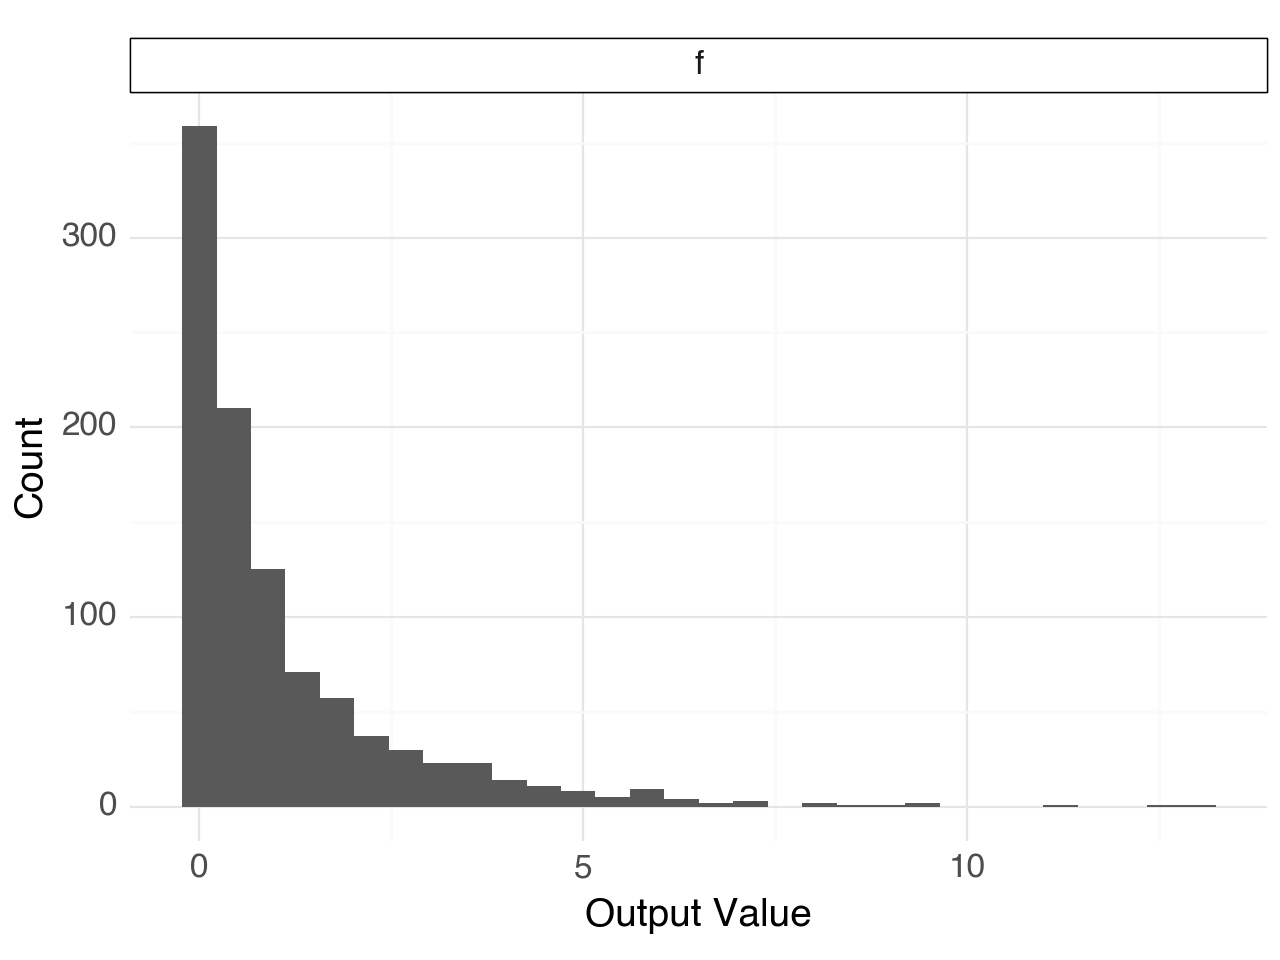

<Figure Size: (640 x 480)>

In [12]:
(
    md_quad1d
    >> gr.ev_sample(df_det="nom", n=1000)
    >> gr.pt_auto()
)

You should use a reasonable sample size; at least 1000, but more is always better.

### Monte Carlo

Monte Carlo is an algorithm we can use to estimate statistics about an output distribution.

In [14]:
## Approximate the mean of the output distribution
(
    md_quad1d
    >> gr.ev_sample(df_det="nom", n=1000)
    >> gr.tf_summarize(
        f_lo=gr.mean_lo(DF.f),
        f_mu=gr.mean(DF.f),
        f_up=gr.mean_up(DF.f),
    )
)

,f_lo,f_mu,f_up
0,0.942765,1.060058,1.17735


The `_lo` and `_up` estimates are the endpoints of a *confidence interval*. This gives us a sense for how precisely we have estimated `f_mu`. You can think of this as a source of *erroneous* uncertainty (noise) coming from our Monte Carlo approximation.

> **The golden rule for interpreting CIs.** When interpreting a CI, we
should assume the population value could be anywhere inside the interval.

In [16]:
## Approximate the probability that F = f(X) > 5
(
    md_quad1d
    >> gr.ev_sample(df_det="nom", n=1000)
    >> gr.tf_summarize(
        pr_lo=gr.pr_lo(DF.f > 5),
        pr_mu=gr.pr(DF.f > 5),
        pr_up=gr.pr_up(DF.f > 5),
    )
)

,pr_lo,pr_mu,pr_up
0,0.014418,0.025,0.043009


#### Monte Carlo Convergence

In [30]:
df_mc = gr.df_grid()
N_all = gr.logspace(1, 4, 10)

for n in N_all:
    df_mc = (
        df_mc
        >> gr.tf_bind_rows(
            md_quad1d
            >> gr.ev_sample(df_det="nom", n=n, seed=101)
            >> gr.tf_summarize(
                pr_lo=gr.pr_lo(DF.f > 5),
                pr_mu=gr.pr(DF.f > 5),
                pr_up=gr.pr_up(DF.f > 5),
            )
            >> gr.tf_mutate(n=n)
        )
    )
    
df_mc        

eval_sample() is rounding n...
eval_sample() is rounding n...
eval_sample() is rounding n...
eval_sample() is rounding n...
eval_sample() is rounding n...
eval_sample() is rounding n...
eval_sample() is rounding n...
eval_sample() is rounding n...
eval_sample() is rounding n...
eval_sample() is rounding n...


,pr_lo,pr_mu,pr_up,n
0,0.000000,0.000000,0.440698,10.000000
1,0.000000,0.000000,0.272839,21.544347
2,0.002228,0.021739,0.181134,46.415888
3,0.001024,0.010000,0.090555,100.000000
4,0.005044,0.018605,0.066203,215.443469
5,0.014562,0.030172,0.061473,464.158883
6,0.015897,0.027000,0.045498,1000.000000
7,0.016826,0.024605,0.035850,2154.434690
8,0.020833,0.026718,0.034208,4641.588834
9,0.020520,0.024500,0.029228,10000.000000


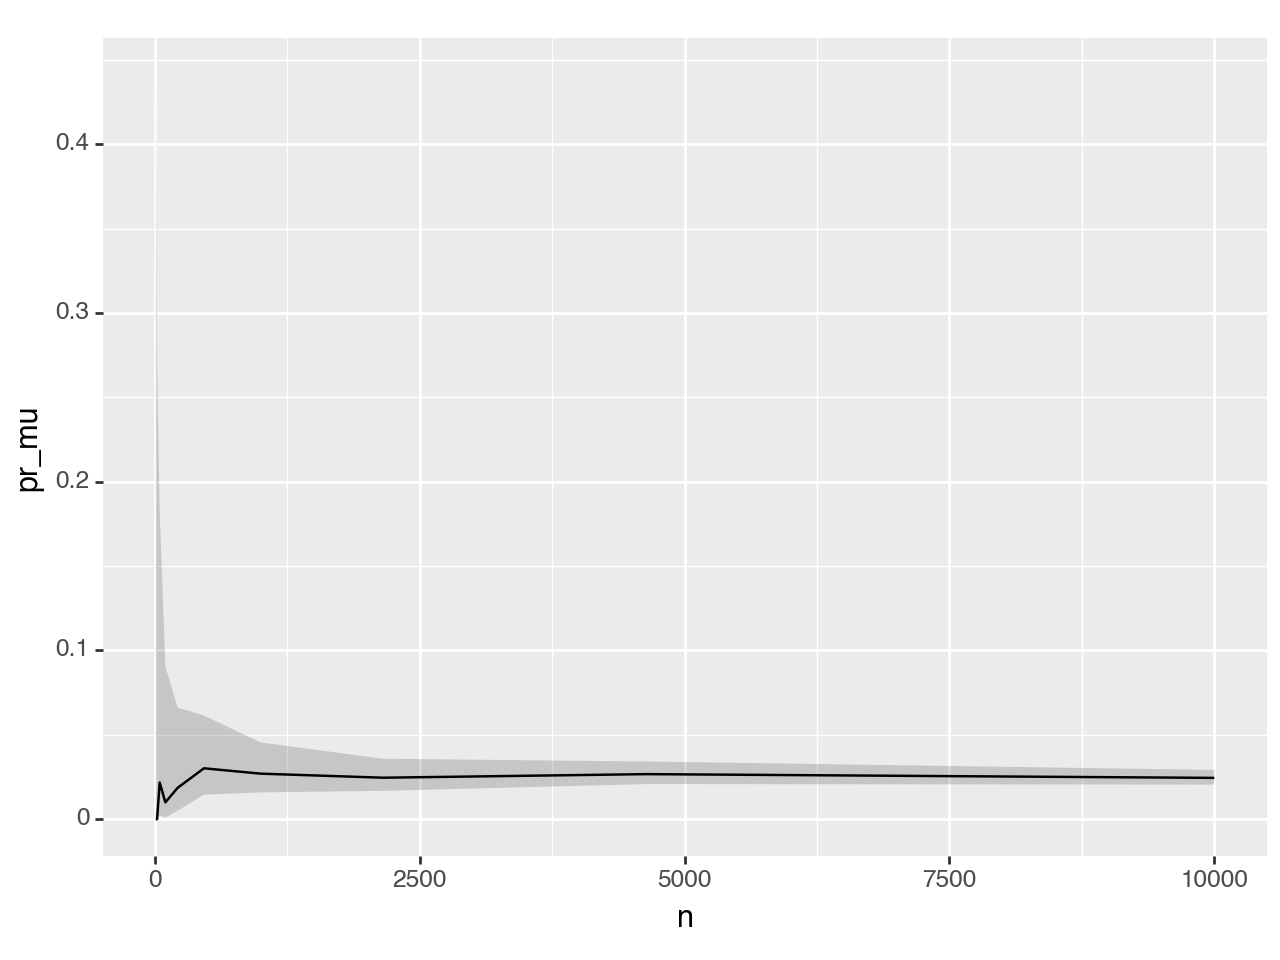

<Figure Size: (640 x 480)>

In [33]:
(
    df_mc
    >> gr.ggplot(gr.aes("n"))
    + gr.geom_ribbon(gr.aes(ymin="pr_lo", ymax="pr_up"), alpha=1/5)
    + gr.geom_line(gr.aes(y="pr_mu"))
    # + gr.scale_x_log10()
    # + gr.scale_y_log10()
)

## Practical Example: Structural Safety

In [18]:
from grama.models import make_cantilever_beam
md_beam = make_cantilever_beam()
md_beam

model: Cantilever Beam

  inputs:
    var_det:
      t: [2, 4]
      w: [2, 4]

    var_rand:
      H: (+1) norm, {'mean': '5.000e+02', 's.d.': '1.000e+02', 'COV': 0.2, 'skew.': 0.0, 'kurt.': 3.0}
      V: (+1) norm, {'mean': '1.000e+03', 's.d.': '1.000e+02', 'COV': 0.1, 'skew.': 0.0, 'kurt.': 3.0}
      E: (+0) norm, {'mean': '2.900e+07', 's.d.': '1.450e+06', 'COV': 0.05, 'skew.': 0.0, 'kurt.': 3.0}
      Y: (-1) norm, {'mean': '4.000e+04', 's.d.': '2.000e+03', 'COV': 0.05, 'skew.': 0.0, 'kurt.': 3.0}

    copula:
      Independence copula

  functions:
      cross-sectional area: ['w', 't'] -> ['c_area']
      limit state: stress: ['w', 't', 'H', 'V', 'E', 'Y'] -> ['g_stress']
      limit state: displacement: ['w', 't', 'H', 'V', 'E', 'Y'] -> ['g_disp']

The beam has two *limit state functions*. Limit states are failure modes for a system. A limit state function is a function $g(x)$ where $g(x) > 0$ corresponds to safe operation, while $g(x) < 0$ corresponds to a failure.

- `g_stress` corresponds to failure due to applied stress exceeding material strength
- `g_disp` corresponds to failure due to excessive beam displacement

We can use a limit state function to define the *probability of failure* according to a given failure mode

$$\text{POF} \equiv Pr[g(x) \leq 0]$$

And we can use Monte Carlo to estiimate the POF for both failure modes

In [19]:
(
    md_beam
    >> gr.ev_sample(df_det="nom", n=1000)
    >> gr.tf_summarize(
        pof_disp_lo=gr.pr_lo(DF.g_disp <= 0),
        pof_disp_mu=gr.pr(DF.g_disp <= 0),
        pof_disp_up=gr.pr_up(DF.g_disp <= 0),
        
        pof_stress_lo=gr.pr_lo(DF.g_stress <= 0),
        pof_stress_mu=gr.pr(DF.g_stress <= 0),
        pof_stress_up=gr.pr_up(DF.g_stress <= 0),
    )
)

,pof_disp_lo,pof_disp_mu,pof_disp_up,pof_stress_lo,pof_stress_mu,pof_stress_up
0,0.025901,0.04,0.061292,0.02121,0.034,0.054076


Let's imagine we wanted less than $3\%$ POF for both failure modes. Do the results indicate that we've achieved this goal?

In [20]:
# Refine the MC sample size
(
    md_beam
    >> gr.ev_sample(df_det="nom", n=1e5)
    >> gr.tf_summarize(
        pof_disp_lo=gr.pr_lo(DF.g_disp <= 0),
        pof_disp_mu=gr.pr(DF.g_disp <= 0),
        pof_disp_up=gr.pr_up(DF.g_disp <= 0),
        
        pof_stress_lo=gr.pr_lo(DF.g_stress <= 0),
        pof_stress_mu=gr.pr(DF.g_stress <= 0),
        pof_stress_up=gr.pr_up(DF.g_stress <= 0),
    )
)

eval_sample() is rounding n...


,pof_disp_lo,pof_disp_mu,pof_disp_up,pof_stress_lo,pof_stress_mu,pof_stress_up
0,0.045314,0.04716,0.049078,0.034422,0.03604,0.037731


In the assignment notebook, I have you define a model that embeds a Monte Carlo analysis so we can do *optimization under uncertainty*. Now we're seeing why I put probability and optimization together!

We can define a similar model to 

Calling plot_sinew_outputs....


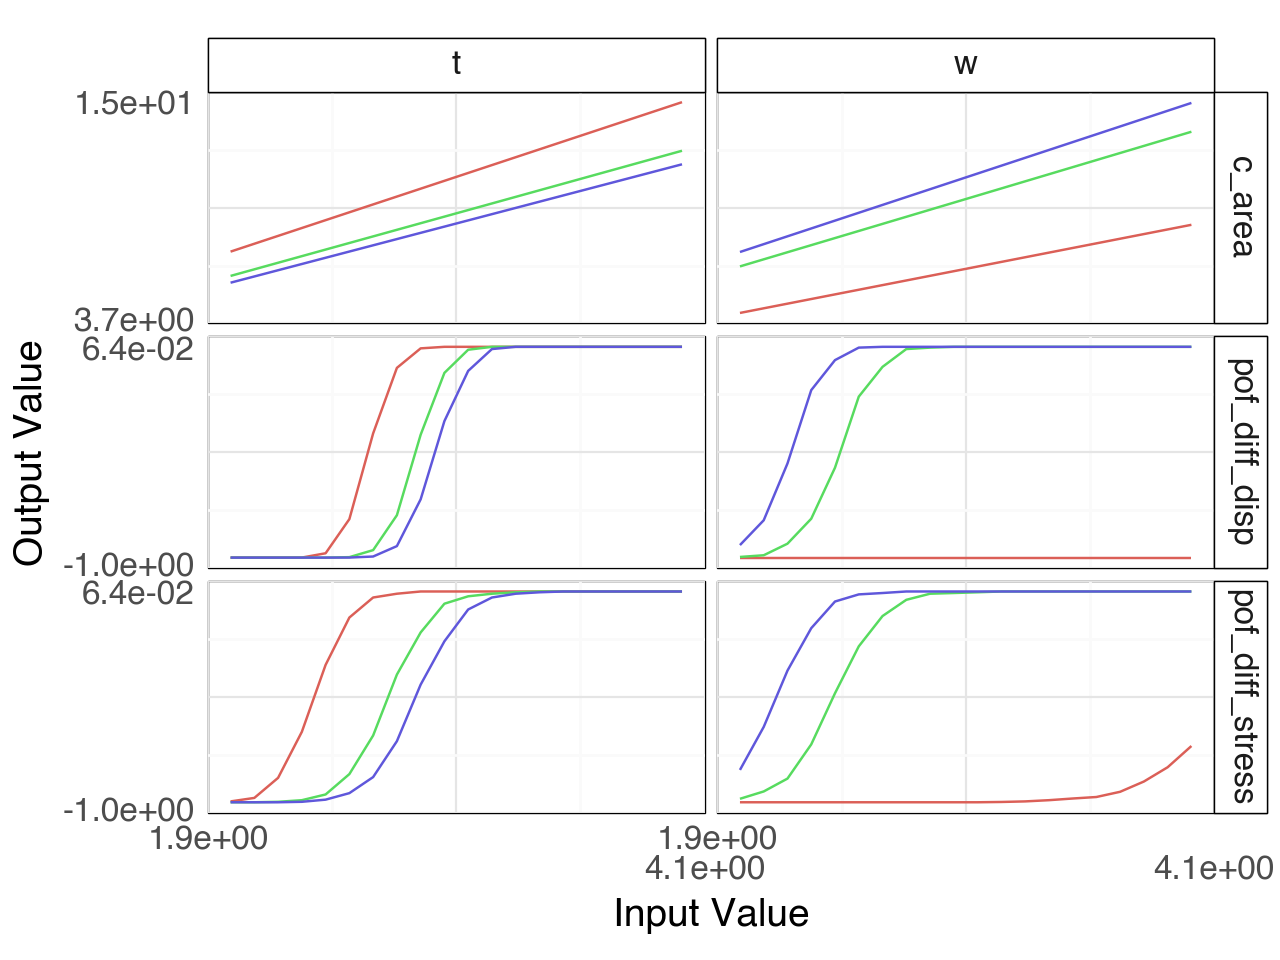

<Figure Size: (640 x 480)>

In [96]:
md_beam_up = (
    gr.Model("Beam UP")
    # We can vectorize with Monte Carlo 
    # if we use common random numbers
    >> gr.cp_function(
        fun=lambda t, w: md_beam
        >> gr.ev_sample(
            df_det=gr.df_make(t=t, w=w), 
            n=500, seed=101
        )
        # I use the upper CI endpoints as
        # a conservative estimate of the POFs
        >> gr.tf_summarize(
            pof_diff_disp=0.03 - gr.pr_up(DF.g_disp <= 0),
            pof_diff_stress=0.03 - gr.pr_up(DF.g_stress <= 0),
        )
        >> gr.tf_mutate(c_area=t*w),
        var=["t", "w"],
        out=["pof_diff_disp", "pof_diff_stress", "c_area"],
    )
    >> gr.cp_bounds(
        t=(2, 4),
        w=(2, 4),
    )
)

(
    md_beam_up
    >> gr.ev_sinews(df_det="swp", n_density=20)
    >> gr.pt_auto()
)

It turns out to be a bad idea to use Monte Carlo within an optimization loop

In [97]:
(
    md_beam_up
    >> gr.ev_min(
        out_min="c_area", 
        out_geq=["pof_diff_disp", "pof_diff_stress"],
        n_restart=3,
        method="SLSQP",
    )
)

Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec


,t,w,t_0,w_0,pof_diff_stress,pof_diff_disp,c_area,success,message,n_iter
0,2.997861,2.997861,3.000000,3.000000,-0.029756,-0.055011,8.98717,False,Positive directional derivative for linesearch,35
1,2.000000,2.000000,2.127942,3.251314,-0.970000,-0.970000,4.00000,False,Positive directional derivative for linesearch,13
2,2.000000,2.000000,3.599212,3.608429,-0.970000,-0.970000,4.00000,False,Positive directional derivative for linesearch,6


As a preview of an advanced technique we'll learn later, let's apply the First Order Reliability Method (FORM) to estimate the POF for each failure model:

Calling plot_sinew_outputs....


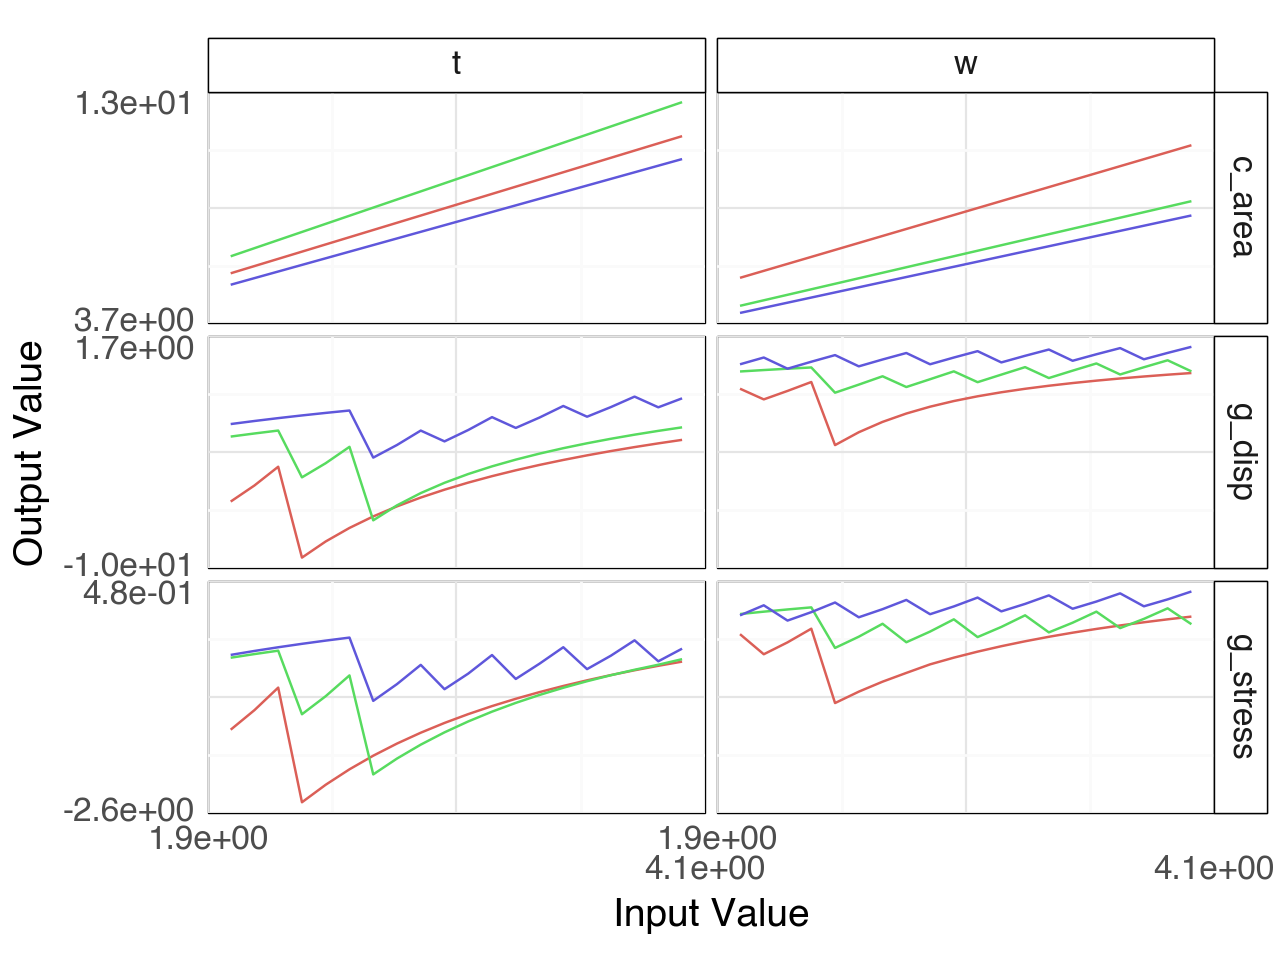

<Figure Size: (640 x 480)>

In [80]:
md_beam_form = (
    gr.Model("Beam Optimization")
    >> gr.cp_vec_function(
        fun=lambda df: gr.df_make(c_area=df.w * df.t),
        var=["w", "t"],
        out=["c_area"],
        name="Area objective",
    )
    >> gr.cp_vec_function(
        fun=lambda df: gr.eval_form_pma(
            md_beam,
            betas=dict(g_stress=3, g_disp=3),
            df_det=df,
            append=False,
        ),
        var=["w", "t"],
        out=["g_stress", "g_disp"],
        name="Reliability constraints",
    )
    >> gr.cp_bounds(w=(2, 4), t=(2, 4))
)

(
    md_beam_form
    >> gr.ev_sinews(df_det="swp", n_density=20)
    >> gr.pt_auto()
)


In [81]:
(
    md_beam_form
    >> gr.ev_min(
        out_min="c_area", 
        out_geq=["g_disp", "g_stress"],
        df_start=gr.df_make(t=3, w=3),
        method="SLSQP",
    )
)

Estimated runtime: 0.0000 sec


,t,w,t_0,w_0,g_stress,c_area,g_disp,success,message,n_iter
0,3.857806,2.459666,3,3,-1.190165e-12,9.488911,1.943726e-07,True,Optimization terminated successfully,7
